In [1]:
# ============================================================
#     IMPORTS
# ============================================================

import pandas as pd
import numpy as np
import os
import pickle

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MultiLabelBinarizer
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report
)


In [2]:
# ============================================================
#    LOAD DATA
# ============================================================

data_path = "../Data"

files = os.listdir(data_path)

all_data = []

for file in files:
    if file.endswith(".csv"):
        df_temp = pd.read_csv(os.path.join(data_path, file))
        df_temp["source_file"] = file
        all_data.append(df_temp)

df = pd.concat(all_data, ignore_index=True)

print("✅ Data Loaded Successfully")
df.head()


✅ Data Loaded Successfully


,Campaign_ID,Campaign_Type,Target_Audience,Duration,Channel_Used,Impressions,Clicks,Leads,Conversions,Revenue,Acquisition_Cost,ROI,Language,Engagement_Score,Customer_Segment,Date,source_file
0,NY-CMP-1000,Social Media,College Students,21.0,"WhatsApp, YouTube",57804.0,6156.0,3616.0,2355.0,1867515.0,NaN,6.14,Hindi,20.98,College Students,29-04-2025,nykaa_campaign_data_with_nulls.csv
1,NY-CMP-1001,Paid Ads,Tier 2 City Customers,18.0,YouTube,91801.0,3321.0,1971.0,1357.0,1046247.0,180.83,3.26,Hindi,7.24,College Students,06-04-2025,nykaa_campaign_data_with_nulls.csv
2,NY-CMP-1002,Influencer,Youth,23.0,"WhatsApp, Google, YouTube",15536.0,2182.0,952.0,755.0,197055.0,90.60,NaN,English,25.03,College Students,14-01-2025,nykaa_campaign_data_with_nulls.csv
3,NY-CMP-1003,Email,Working Women,18.0,"YouTube, Facebook, Instagram",88114.0,8413.0,2231.0,947.0,376906.0,249.07,0.60,Hindi,13.15,NaN,04-06-2025,nykaa_campaign_data_with_nulls.csv
4,NY-CMP-1004,Paid Ads,College Students,10.0,"Facebook, Instagram",96871.0,3743.0,2060.0,1258.0,518296.0,228.60,0.80,Hindi,7.29,Tier 2 City Customers,29-12-2024,nykaa_campaign_data_with_nulls.csv


In [3]:
# ============================================================
#   BASIC INFO
# ============================================================

print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())


Dataset Shape:
(166665, 17)

Column Names:
Index(['Campaign_ID', 'Campaign_Type', 'Target_Audience', 'Duration',
       'Channel_Used', 'Impressions', 'Clicks', 'Leads', 'Conversions',
       'Revenue', 'Acquisition_Cost', 'ROI', 'Language', 'Engagement_Score',
       'Customer_Segment', 'Date', 'source_file'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 166665 entries, 0 to 166664
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Campaign_ID       161248 non-null  object 
 1   Campaign_Type     158307 non-null  object 
 2   Target_Audience   158493 non-null  object 
 3   Duration          158342 non-null  float64
 4   Channel_Used      158383 non-null  object 
 5   Impressions       158441 non-null  float64
 6   Clicks            158441 non-null  float64
 7   Leads             158575 non-null  float64
 8   Conversions       158665 non-null  float64
 9  

In [4]:

# ============================================================
#    DATA CLEANING
# ============================================================

df.drop_duplicates(inplace=True)

for col in df.columns:
    if df[col].dtype == "object":
        df[col].fillna("Unknown", inplace=True)
    else:
        df[col].fillna(df[col].median(), inplace=True)

print("✅ Data Cleaning Completed")
print("\nRemaining Missing Values:")
print(df.isnull().sum())


✅ Data Cleaning Completed

Remaining Missing Values:
Campaign_ID         0
Campaign_Type       0
Target_Audience     0
Duration            0
Channel_Used        0
Impressions         0
Clicks              0
Leads               0
Conversions         0
Revenue             0
Acquisition_Cost    0
ROI                 0
Language            0
Engagement_Score    0
Customer_Segment    0
Date                0
source_file         0
dtype: int64


In [5]:
# ============================================================
#-  FEATURE ENGINEERING
# ============================================================

# ROI Calculation
df["ROI"] = (
    (df["Revenue"] - df["Acquisition_Cost"]) /
    (df["Acquisition_Cost"] + 1)
)

# Profit Flag
df["Profit_Flag"] = np.where(df["ROI"] > 0, 1, 0)

print("✅ Feature Engineering Completed")
df[["Revenue", "Acquisition_Cost", "ROI", "Profit_Flag"]].head()


✅ Feature Engineering Completed


,Revenue,Acquisition_Cost,ROI,Profit_Flag
0,1867515.0,208.725,8903.594111,1
1,1046247.0,180.830,5752.989991,1
2,197055.0,90.600,2150.266376,1
3,376906.0,249.070,1506.205982,1
4,518296.0,228.600,2256.391115,1


In [6]:
# ============================================================
#    MULTI-LABEL ENCODING (Channel_Used)
# ============================================================

df["Channel_Used"] = df["Channel_Used"].apply(
    lambda x: [i.strip() for i in str(x).split(",")]
)

mlb = MultiLabelBinarizer()

channel_encoded = pd.DataFrame(
    mlb.fit_transform(df["Channel_Used"]),
    columns=mlb.classes_
)

df = pd.concat([df.reset_index(drop=True), channel_encoded], axis=1)

print("✅ Multi-Label Encoding Completed")
print("\nEncoded Channels:")
print(mlb.classes_)


✅ Multi-Label Encoding Completed

Encoded Channels:
['Email' 'Facebook' 'Google' 'Instagram' 'Unknown' 'WhatsApp' 'YouTube']


In [7]:
# ============================================================
#   LABEL ENCODING (Categorical Columns)
# ============================================================

categorical_cols = [
    "Campaign_Type",
    "Target_Audience",
    "Language",
    "Customer_Segment",
    "source_file"
]

label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le   # ← save each encoder for later use in Streamlit

print("✅ Label Encoding Completed")
df.head()


✅ Label Encoding Completed


,Campaign_ID,Campaign_Type,Target_Audience,Duration,Channel_Used,Impressions,Clicks,Leads,Conversions,Revenue,...,Date,source_file,Profit_Flag,Email,Facebook,Google,Instagram,Unknown,WhatsApp,YouTube
0,NY-CMP-1000,4,0,21.0,"[WhatsApp, YouTube]",57804.0,6156.0,3616.0,2355.0,1867515.0,...,29-04-2025,0,1,0,0,0,0,0,1,1
1,NY-CMP-1001,2,2,18.0,[YouTube],91801.0,3321.0,1971.0,1357.0,1046247.0,...,06-04-2025,0,1,0,0,0,0,0,0,1
2,NY-CMP-1002,1,5,23.0,"[WhatsApp, Google, YouTube]",15536.0,2182.0,952.0,755.0,197055.0,...,14-01-2025,0,1,0,0,1,0,0,1,1
3,NY-CMP-1003,0,4,18.0,"[YouTube, Facebook, Instagram]",88114.0,8413.0,2231.0,947.0,376906.0,...,04-06-2025,0,1,0,1,0,1,0,0,1
4,NY-CMP-1004,2,0,10.0,"[Facebook, Instagram]",96871.0,3743.0,2060.0,1258.0,518296.0,...,29-12-2024,0,1,0,1,0,1,0,0,0


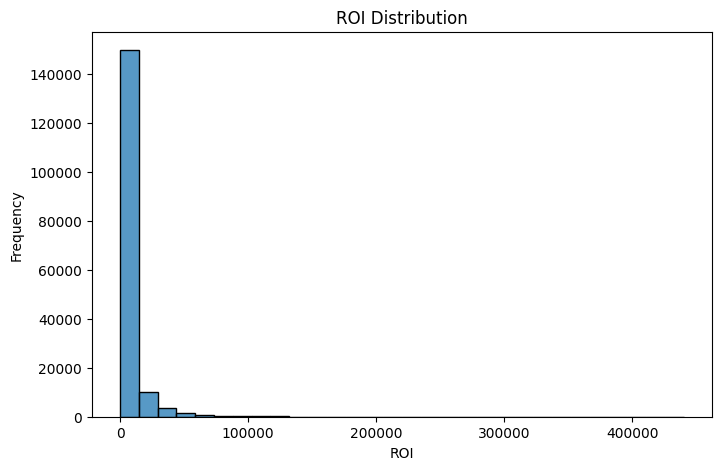

In [8]:
# ============================================================
#  EDA: ROI Distribution
# ============================================================

plt.figure(figsize=(8, 5))
sns.histplot(df["ROI"], bins=30)
plt.title("ROI Distribution")
plt.xlabel("ROI")
plt.ylabel("Frequency")
plt.show()


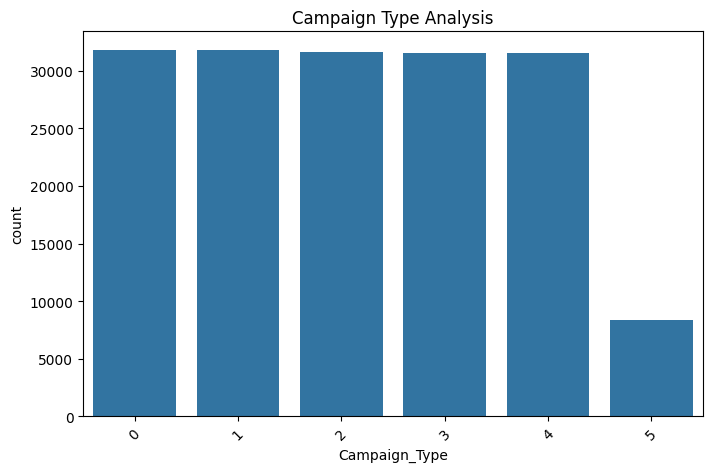

In [9]:
# ============================================================
#   EDA: Campaign Type Analysis
# ============================================================

plt.figure(figsize=(8, 5))
sns.countplot(x=df["Campaign_Type"])
plt.title("Campaign Type Analysis")
plt.xticks(rotation=45)
plt.show()


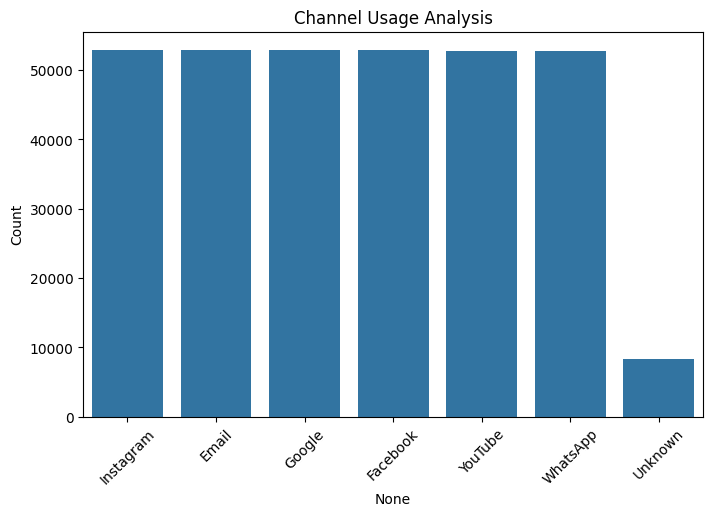

In [10]:
# ============================================================
#     EDA: Channel Usage
# ============================================================

channel_counts = channel_encoded.sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=channel_counts.index, y=channel_counts.values)
plt.title("Channel Usage Analysis")
plt.xticks(rotation=45)
plt.ylabel("Count")
plt.show()


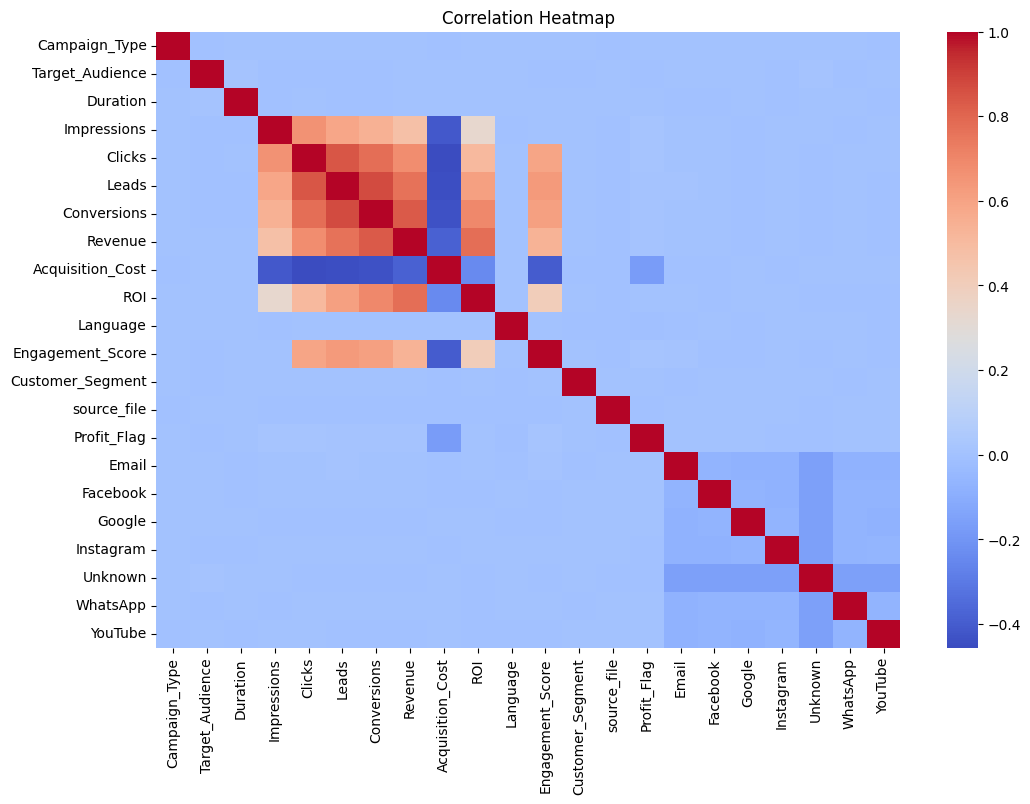

In [11]:
# ============================================================
#    EDA: Correlation Heatmap
# ============================================================

plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [12]:
# ============================================================
# REGRESSION MODEL (Predict Revenue)
# ============================================================

# Drop columns not needed for regression
X_reg = df.drop(columns=["Revenue", "Campaign_ID", "Channel_Used", "Date"])
y_reg = df["Revenue"]

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

regressor = RandomForestRegressor(n_estimators=50, random_state=42)
regressor.fit(X_train_reg, y_train_reg)

y_pred_reg = regressor.predict(X_test_reg)

print("✅ Regression Model Trained Successfully")


✅ Regression Model Trained Successfully


In [13]:
# ============================================================
#     REGRESSION EVALUATION
# ============================================================

mae  = mean_absolute_error(y_test_reg, y_pred_reg)
mse  = mean_squared_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mse)
r2   = r2_score(y_test_reg, y_pred_reg)

print("📈 Regression Model Evaluation")
print("\nMAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2  :", r2)


📈 Regression Model Evaluation

MAE : 2457.369923499235
MSE : 172198814.29540762
RMSE: 13122.454583476661
R2  : 0.999240059179078


In [14]:
# ============================================================
#    CLASSIFICATION MODEL (Predict Profit/Loss)
# ============================================================

# Drop columns not needed — also drop ROI to avoid data leakage
X_clf = df.drop(columns=["Profit_Flag", "ROI", "Campaign_ID", "Channel_Used", "Date"])
y_clf = df["Profit_Flag"]

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42
)

classifier = RandomForestClassifier(n_estimators=50, random_state=42)
classifier.fit(X_train_clf, y_train_clf)

y_pred_class = classifier.predict(X_test_clf)

print("✅ Classification Model Trained Successfully")


✅ Classification Model Trained Successfully


In [15]:
# ============================================================
#   CLASSIFICATION EVALUATION
# ============================================================

accuracy  = accuracy_score(y_test_clf, y_pred_class)
precision = precision_score(y_test_clf, y_pred_class)
recall    = recall_score(y_test_clf, y_pred_class)

print("📊 Classification Evaluation")
print("\nAccuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)


📊 Classification Evaluation

Accuracy : 0.999969999699997
Precision: 0.999969999699997
Recall   : 1.0


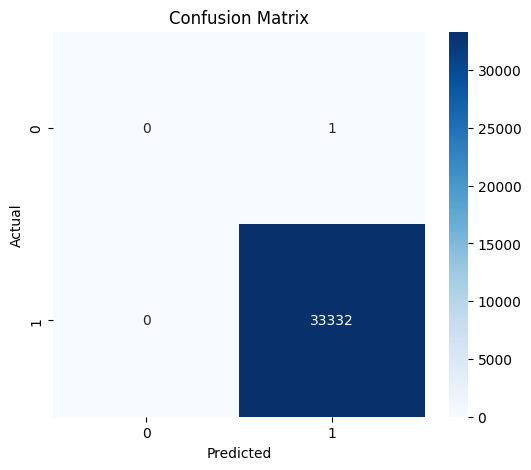

In [16]:
# ============================================================
#     CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_test_clf, y_pred_class)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [17]:
# ============================================================
#  CLASSIFICATION REPORT
# ============================================================

print(classification_report(y_test_clf, y_pred_class))


              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       1.00      1.00      1.00     33332

    accuracy                           1.00     33333
   macro avg       0.50      0.50      0.50     33333
weighted avg       1.00      1.00      1.00     33333



c:\Users\THAHEER\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\THAHEER\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\THAHEER\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

In [18]:
# ============================================================
#   FEATURE IMPORTANCE
# ============================================================

importance = pd.DataFrame({
    "Feature"   : X_clf.columns,
    "Importance": classifier.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("📌 Top Important Features")
importance.head(10)


📌 Top Important Features


,Feature,Importance
8,Acquisition_Cost,0.342357
6,Conversions,0.195576
7,Revenue,0.179763
5,Leads,0.064118
4,Clicks,0.041469
10,Engagement_Score,0.039580
3,Impressions,0.024619
2,Duration,0.019426
11,Customer_Segment,0.018361
1,Target_Audience,0.018006


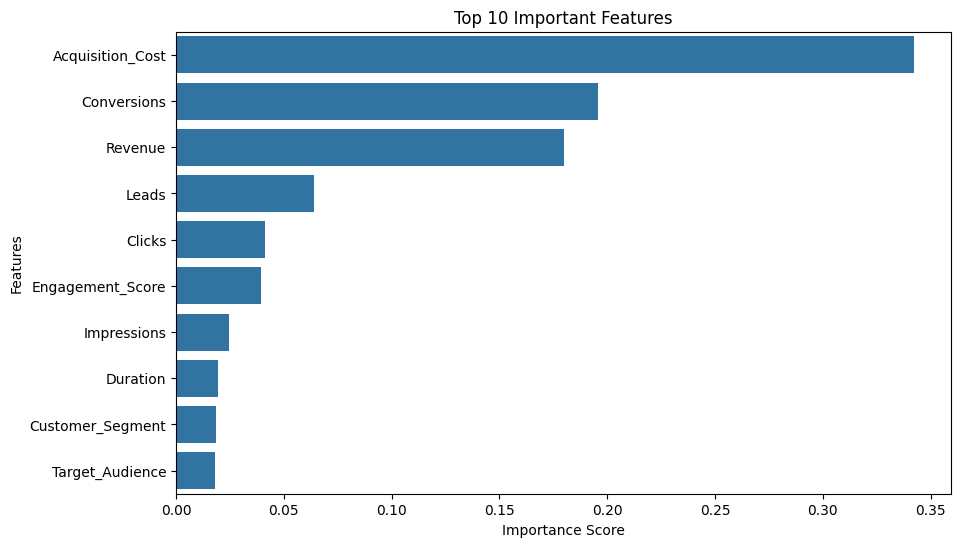

In [19]:
# ============================================================
# FEATURE IMPORTANCE CHART
# ============================================================

plt.figure(figsize=(10, 6))
sns.barplot(
    x=importance["Importance"].head(10),
    y=importance["Feature"].head(10)
)
plt.title("Top 10 Important Features")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()


In [20]:
# ============================================================
#    SAVE PICKLE FILES 
# ============================================================

os.makedirs("models", exist_ok=True)

# Regression model
with open("models/reg_model.pkl", "wb") as f:
    pickle.dump(regressor, f)

# Classification model
with open("models/clf_model.pkl", "wb") as f:
    pickle.dump(classifier, f)

# Feature column names (so Streamlit knows exact input columns)
with open("models/reg_columns.pkl", "wb") as f:
    pickle.dump(list(X_reg.columns), f)

with open("models/clf_columns.pkl", "wb") as f:
    pickle.dump(list(X_clf.columns), f)

# MultiLabelBinarizer (for channel encoding in Streamlit)
with open("models/mlb_encoder.pkl", "wb") as f:
    pickle.dump(mlb, f)

# Label encoders (for categorical columns in Streamlit)
with open("models/label_encoders.pkl", "wb") as f:
    pickle.dump(label_encoders, f)

print("✅ All 6 Pickle Files Saved in /models folder!")
print("   - models/reg_model.pkl")
print("   - models/clf_model.pkl")
print("   - models/reg_columns.pkl")
print("   - models/clf_columns.pkl")
print("   - models/mlb_encoder.pkl")
print("   - models/label_encoders.pkl")
print("\n🎯 Now run:  streamlit run app.py")

✅ All 6 Pickle Files Saved in /models folder!
   - models/reg_model.pkl
   - models/clf_model.pkl
   - models/reg_columns.pkl
   - models/clf_columns.pkl
   - models/mlb_encoder.pkl
   - models/label_encoders.pkl

🎯 Now run:  streamlit run app.py
